 Step:- 1 , Initial Date type Audit
Activity_Date    str
Workout_Type     str
dtype: object


=== 🏋️‍♂️ STEP 4: WORKOUT SUMMARY AGGREGATION ===
    Workout_Type  Total_Sessions  Total_Hours_Trained  \
0         Cardio              36                39.25   
1       Rest_Day               8                 0.00   
2  Weightlifting              35                37.25   
3           Yoga               7                 7.75   

   Average_Calories_Per_Session  
0                    438.007068  
1                      0.000000  
2                    452.166238  
3                    439.442493  



C:\Users\hp\AppData\Local\Temp\ipykernel_7568\2930704088.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Workout_Type', y='Total_Hours_Trained', data=fitness_summary, palette='Set1', ax=axes[1])


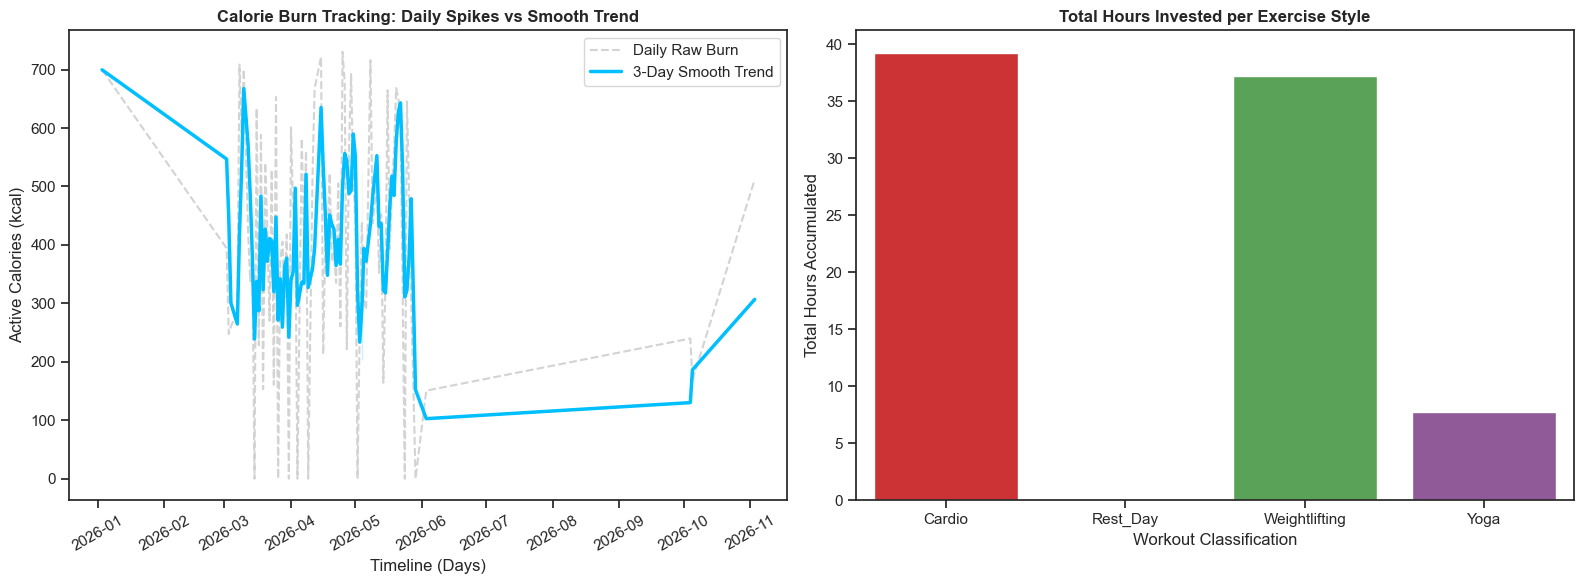

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Read out raw fitness data 
df = pd.read_csv('dirty_fitness_tracker.csv')

print(" Step:- 1 , Initial Date type Audit" )
print(df[['Activity_Date', 'Workout_Type']].dtypes)
print("\n=======================================\n")

# 1. Standardizing Date Formats and Chronological Sorting
# Probelem : Date are in the format of dd-mm-yy or dd/mm/yy so fixed it to DD/MM/YYYY format
df['Activity_Date'] = pd.to_datetime(df['Activity_Date'], format='mixed')
df = df.sort_values(by='Activity_Date').reset_index(drop=True)

# 2. Clearing Data Outliers &n Missing Values
# Drop neagtive duration but keep rest days (0 minutes) safely
df = df[df['Duration_Minutes'] >= 0]

# Filling missing value of 'Duration_Minutes'with median by type of workout duration
df['Duration_Minutes']= df['Duration_Minutes'].fillna(
    df.groupby('Workout_Type')['Duration_Minutes'].transform('median')
)
# 3. ADVANCED ROLLING WINDOWS (THE MOVING AVERAGE)
# Smooth out daily spikes to find your real weekly calorie burning trend
# window=3 means it takes (Yesterday + Today + Tomorrow) / 3
df['Rolling_3Day_Calorie_Avg'] = df['Calories_Burned'].rolling(window=3, min_periods=1).mean()

# Weekly Activity Aggregation
fitness_summary = df.groupby('Workout_Type').agg(
    Total_Sessions = ('Activity_Date','count'),
    Total_Hours_Trained = ("Duration_Minutes", lambda x: x.sum()/60),
    Average_Calories_Per_Session = ('Calories_Burned','mean')
).reset_index()

print("=== 🏋️‍♂️ STEP 4: WORKOUT SUMMARY AGGREGATION ===")
print(fitness_summary)
print("=========================================\n")

# =====================================================================
# 5. TIME-SERIES VISUALIZATION
# =====================================================================
sns.set_theme(style="ticks")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Line Chart showing raw daily burn vs the smoothed Rolling Average line
sns.lineplot(x='Activity_Date', y='Calories_Burned', data=df, ax=axes[0], color='lightgray', label='Daily Raw Burn', linestyle='--')
sns.lineplot(x='Activity_Date', y='Rolling_3Day_Calorie_Avg', data=df, ax=axes[0], color='deepskyblue', linewidth=2.5, label='3-Day Smooth Trend')
axes[0].set_title('Calorie Burn Tracking: Daily Spikes vs Smooth Trend', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Timeline (Days)')
axes[0].set_ylabel('Active Calories (kcal)')
axes[0].tick_params(axis='x', rotation=30)

# Chart 2: Categorical Bar Chart showing time spent per workout category
sns.barplot(x='Workout_Type', y='Total_Hours_Trained', data=fitness_summary, palette='Set1', ax=axes[1])
axes[1].set_title('Total Hours Invested per Exercise Style', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Workout Classification')
axes[1].set_ylabel('Total Hours Accumulated')

plt.tight_layout()
plt.show()